In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from scipy.optimize import curve_fit
import camb
from camb import model, initialpower

In [5]:
omega_r = 8.5e-5
omch2 = 0.1157
ombh2 = 0.0225
h0 = 0.6766
omega_m = (omch2+ombh2)/h0**2
omega_l = 1-omega_m
omega_c  = 1.0-omega_r-omega_m-omega_l

# z = np.linspace(0.0, 6.0, 200)
# a = 1/(1+z)
# a = a[::-1]
a = np.loadtxt("a_bg.txt")
expf = np.sqrt (omega_r/a**4 + omega_m/a**3 + omega_l + omega_c/a**2)

print(f"{a[0]} {a[-1]}")

0.14285714285714285 1.0


In [10]:
def cheb(c,a) :
    x = np.arccos(a)
    result = 0
    for i in range(len(c)) :
        if i ==0 :
            result += (1/np.pi)**(1/2)*c[i]
        else :
            result += (2/np.pi)**(1/2)*c[i]*np.cos(i*x)
    return result

def model(a,*c) :
    da = (1-a[0])/a[0]
    x = (a-a[0])/(a[-1]-a[0])
    h0 = 0.6898
    expf = da / (1 + da * x)**2 / cheb(c,2*x-1) / h0
    expf = expf/expf[-1]
    return expf

In [12]:
# Fitting Inverse model
n_coefs = 4
p0 = np.ones(n_coefs)
params, covariance = curve_fit(model,a,expf,p0)
c = params
print(params)
# c[0] = -1000
# a=np.linspace(0,1,200)
# expf = np.sqrt (omega_r/a**4 + omega_m/a**3 + omega_l + omega_c/a**2)
# plt.plot(a,expf, label = "ori")
# plt.plot(a,inv_model(a,*c), label = "cheb")
# plt.ylim(0,100)
# plt.legend()

[ 204.83563834  -73.71625095 -189.12502733  117.90728052]


In [39]:
n_coefs = 10
p0 = np.ones(n_coefs)
params, covariance = curve_fit(model3,a,expf,p0)
c = params
print(params)
# c[0] = -1000
# a=np.linspace(0,1,200)
# expf = np.sqrt (omega_r/a**4 + omega_m/a**3 + omega_l + omega_c/a**2)
plt.plot(a,expf, label = "ori")
plt.plot(a,model3(a,*c), label = "cheb")
# plt.ylim(0,100)
plt.legend()

/tmp/ipykernel_21368/1436409411.py:7: RuntimeWarning: divide by zero encountered in divide
  expf = da/h0/(1+da*y)**2*(1/cheb_poly(y))


RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 2200.

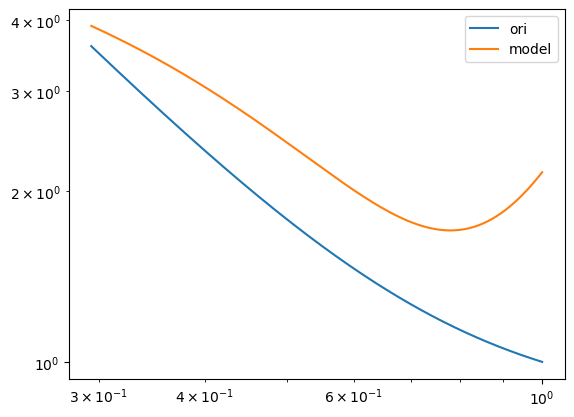

In [40]:
c1 = 0.944
c2 = -0.357
c3 = 0.047
c4 = 0.0052
# indep = model(a,c1,c2,c3)
indep2 = model2(a,c1,c2,c3,c4)
plt.plot(a,expf, label = "ori")
plt.loglog(a,indep, label = "model")
plt.legend()

In [17]:
np.any(indep==0)

False

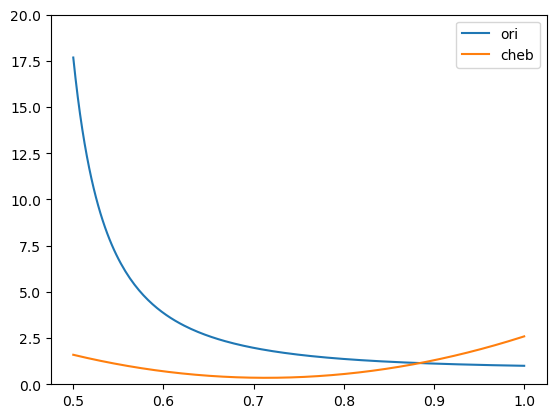

In [5]:
a=np.linspace(0.5,1,200)
plt.plot(a,expf, label = "ori")
plt.plot(a,model(a,*c), label = "cheb")
plt.ylim(0,20)
plt.legend()

In [48]:
model(0.2,*c)

-688.9200778807365

In [49]:
def expansion_function (a):
    # For odeint to work
    aa = np.loadtxt("a_distance.txt")
    a0 = aa[0]
    aEnd = aa[-1]
    cheb_poly = np.polynomial.chebyshev.Chebyshev(params, domain=[a0,aEnd])
    # cheb_poly = np.polynomial.chebyshev.Chebyshev([self.c1,self.c2,self.c3,self.c4,self.c5,self.c6,self.c7,self.c8,self.c9,self.c10,self.c11,self.c12,self.c13,self.c14,self.c15], domain=[a0,aEnd])
    expf = 0.6766*cheb_poly(a)
    # np.savetxt("expf", expf)
    return expf

def d_expansion_function_d_a (a):
    # For odeint to work
    aa = np.loadtxt("a_distance.txt")
    a0 = aa[0]
    aEnd = aa[-1]

    cheb_poly = np.polynomial.chebyshev.Chebyshev(params, domain=[a0,aEnd])
    cheb_deriv = cheb_poly.deriv()
    d_expf = 0.6766*cheb_deriv(a)
    return d_expf

(-100.0, 100.0)

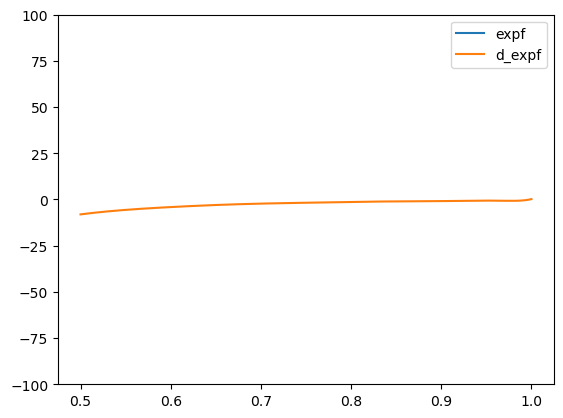

In [50]:
plt.plot(a,expansion_function(a),label="expf")
plt.plot(a,d_expansion_function_d_a(a),label="d_expf")
plt.legend()
plt.ylim(-100,100)

In [2]:
def model (x,*c) :
    h0 = 0.6766
    cheb_poly = np.polynomial.chebyshev.Chebyshev(c, domain=[0.0,1.0])
    return h0*cheb_poly(x)
def inv_model (a,*c) :
    h0 = 0.6766
    cheb_poly = np.polynomial.chebyshev.Chebyshev(c, domain=[0.0,1.0])
    da = (1-a[0])/a[0]
    x = (a-a[0])/(a[-1]-a[0])
    expf = da*h0/(1+da*x)**2/(cheb_poly(x))
    return expf/expf[-1]
def model2 (x,*c) :
    h0 = 0.6766
    cheb_poly = np.polynomial.chebyshev.Chebyshev(c, domain=[0.0,1.0],window = [0.0,1.0])
    a = np.linspace(0.14,1.0,200)
    da = (1-a[0])/a[0]
    y = (a-a[0])/(a[-1]-a[0])
    expf = da*h0/(1+da*y)**2/cheb_poly(x)
    return expf/expf[-1]
def model3 (x,*c) :
    h0 = 0.6766
    # a = np.linspace(0.14,1.0,200)
    cheb_poly = np.polynomial.chebyshev.Chebyshev(c, domain=[0.0,1.0])
    da = (1-a[0])/a[0]
    y = (a-a[0])/(a[-1]-a[0])
    expf = da/h0/(1+da*y)**2*(1/cheb_poly(y))
    return expf/expf[-1]

In [ ]:
# c1 = 0.944
# c2 = -0.357
# c3 = 0.047
# c4 = 0.0052
c1 = 0.9299689058719247
c2 = -1.0459554490793301
c3 = 0.372718751566417
# indep = model(a,c1,c2,c3)
# indep2 = model2(a,c1,c2,c3,c4)
# indep3 = model3(a,c1,c2,c3,c4)
indep4 = inv_model(a,c1,c2,c3)
# plt.figure(figsize=(10,5))

# plt.subplot(1,2,1)
plt.loglog(a,expf, label = "ori")
plt.loglog(a,indep4, label = "inv_model")
plt.legend()

# plt.subplot(1,2,2)
# plt.loglog(a,expf, label = "ori")
# plt.loglog(a,indep3, label = "model3")
# plt.legend()